In [ ]:
%pip install mlflow
%pip install --upgrade jinja2
%pip install --upgrade Flask
%pip install setuptools
%pip install xgboost

In [2]:
import mlflow

In [3]:
from mlflow import MlflowClient
from pprint import pprint
from sklearn.ensemble import RandomForestRegressor


#### **Analyse exploratoire de données**

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données (remplace par le vrai nom de ton fichier)
df = pd.read_csv('data/Loan_Data.csv')

# Afficher les 5 premières lignes
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['customer_id','default']) # On enlève la cible et l'ID
y = df['default'] # La cible est la colonne 'default'


# Split du dataset (On garde 20% des données pour le test final)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Nombre de clients pour l'entraînement : {len(X_train)}")
print(f"Nombre de clients pour le test : {len(X_test)}")


Nombre de clients pour l'entraînement : 8000
Nombre de clients pour le test : 2000


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# 2. "Apprendre" la moyenne et l'écart-type sur le train ET transformer
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transformer le test avec les mêmes paramètres (sans ré-apprendre !)
X_test_scaled = scaler.transform(X_test)

#### **Création de l'expérience Logistic_Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, roc_auc_score, f1_score, confusion_matrix, precision_score, recall_score
import os
import numpy as np 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [10]:
client = MlflowClient(tracking_uri="http://localhost:8080")

In [11]:

experiment_description = (
   "Évaluation des modèles pour la prédiction du défaut de paiement sur des prêts personnels bancaires."
)


experiment_tags = {# tags servant à l'étiquettage et filtrage de nos expériences
    "project_name": "Pret_Bancaire_MLOps",
    "team_sector": "Banque_Detail",  
    "mlops_stage": "Model_Engineering",
    "mlflow.note.content": "experiment_description"
}


logistic_default = client.create_experiment(  # Nom de l'objet servant de connexion avec le dossier "Default_models" sur MLflow
    name="Logistic_Regression",  # Nom du dossier sur MLflow
    tags=experiment_tags
)

In [13]:
# Set the global tracking URI for MLflow

mlflow.set_tracking_uri("http://localhost:8080")

Accuracy: 0.995
ROC AUC Score: 0.9999495560936239
F1 Score: 0.9855072463768116
Confusion Matrix:


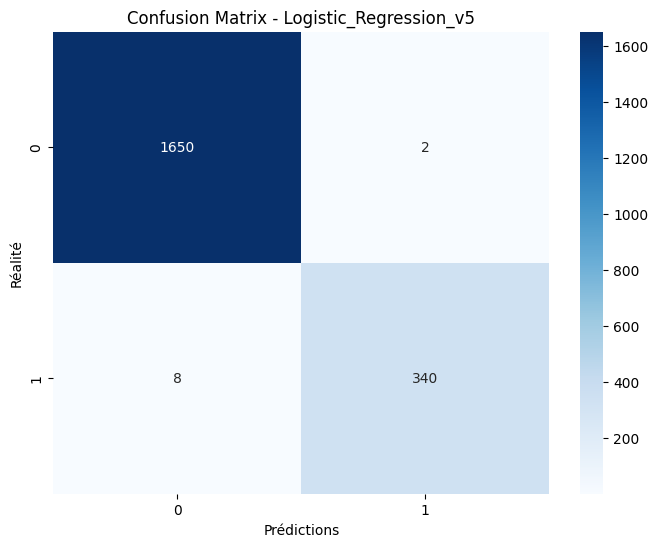

2026/04/11 00:50:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 00:50:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Logistic_Regression_v5 at: http://localhost:8080/#/experiments/1/runs/bfbfe1fa8f7d46cb9342a34456004c29
🧪 View experiment at: http://localhost:8080/#/experiments/1


In [ ]:

logistic_experiment = mlflow.set_experiment("Logistic_Regression")  # Nom du dossier sur MLflow

# If this is not set, a unique name will be auto-generated for your run.
run_name = "Logistic_Regression_v4"

# Define an artifact path that the model will be saved to.
artifact_path = "lr_v4"

params =  {"C": 0.5,       # Calculer l'ordonnée à l'origine (constante)
        "max_iter": 1000,              # Copier les données pour éviter de modifier l'original
        "solver": "lbfgs"  
}


lr = LogisticRegression(**params)
lr.fit(X_train_scaled, y_train)        
y_pred = lr.predict(X_test_scaled)
y_probs = lr.predict_proba(X_test_scaled)[:, 1]

# metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs) 
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)  

# --- AJOUT DU SCRIPT POUR LE GRAPHIQUE ---
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix - {run_name}')
ax.set_xlabel('Prédictions')
ax.set_ylabel('Réalité')

print(f"Accuracy: {accuracy}")
print(f"ROC AUC Score: {roc_auc}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")    
plt.show()

metrics = {"accuracy" : accuracy, "precision": precision, "recall": recall, "roc_auc": roc_auc, "f1": f1}   

if mlflow.active_run():
    mlflow.end_run()  # Terminer la session si erreur

with mlflow.start_run(run_name=run_name) as run:
        mlflow.log_params(params)  # Log des hyperparamètres
        mlflow.log_metrics(metrics)  # Log des métriques
        mlflow.sklearn.log_model(sk_model=lr, input_example=X_test_scaled, artifact_path=artifact_path)  # Log du modèle



#### **Création de l'expérience Random Forest**

In [ ]:

experiment_description = (
   "Évaluation des modèles pour la prédiction du défaut de paiement sur des prêts personnels bancaires."
)


experiment_tags = {# tags servant à l'étiquettage et filtrage de nos expériences
    "project_name": "Pret_Bancaire_MLOps",
    "team_sector": "Banque_Detail",  
    "mlops_stage": "Model_Engineering",
    "mlflow.note.content": "experiment_description"
}


logistic_default = client.create_experiment(  # Nom de l'objet servant de connexion avec le dossier "Default_models" sur MLflow
    name="Random_Forest",  # Nom du dossier sur MLflow
    tags=experiment_tags
)


2026/04/11 01:10:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 01:10:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run Random_Forest_v4 at: http://localhost:8080/#/experiments/2/runs/d9c839f7707642e7b772c55d82f47116
🧪 View experiment at: http://localhost:8080/#/experiments/2


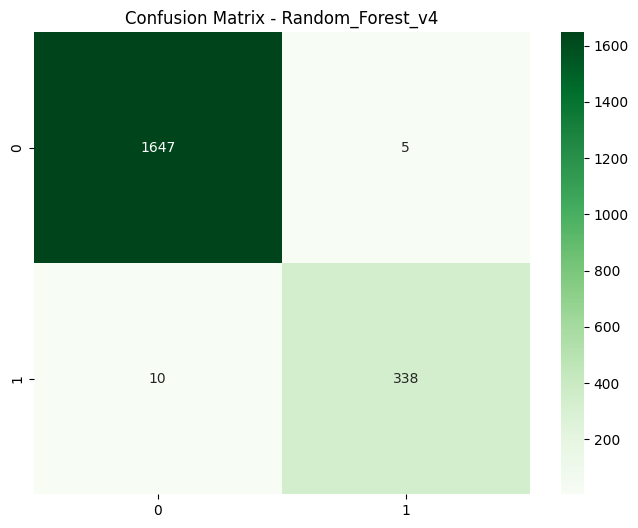

In [ ]:

# 2. On change le nom de l'expérience et du run
rf_experiment = mlflow.set_experiment("Random_Forest") 
run_name = "Random_Forest_v4"
artifact_path = "rf_v4"

# 3. Nouveaux hyperparamètres spécifiques au Random Forest
params = {
    "n_estimators": 100,    # Nombre d'arbres
    "max_depth": 6,        # Profondeur max des arbres
    "random_state": 888,
    "min_samples_split": 15
}


# 4. Initialisation du Random Forest
rf = RandomForestClassifier(**params)
rf.fit(X_train_scaled, y_train)        

# Le reste du code de prédiction reste identique (merci scikit-learn !)
y_pred = rf.predict(X_test_scaled)
y_probs = rf.predict_proba(X_test_scaled)[:, 1]

# --- Calcul des métriques ---
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs) 
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
metrics = {"accuracy" : accuracy, "precision": precision, "recall": recall, "roc_auc": roc_auc, "f1": f1}

# --- Graphique ---
conf_matrix = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', ax=ax) # Changement de couleur pour varier
ax.set_title(f'Confusion Matrix - {run_name}')

# --- MLflow ---
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_params(params)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(sk_model=rf, input_example=X_test_scaled, artifact_path=artifact_path)

plt.show()

#### **Création de l'expérience XGBoost**

2026/04/11 01:15:49 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Models' does not exist. Creating a new experiment.
2026/04/11 01:15:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 01:15:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run XGBoost_v1 at: http://localhost:8080/#/experiments/3/runs/4ef26e835c4f4c7394e305850365e0ab
🧪 View experiment at: http://localhost:8080/#/experiments/3


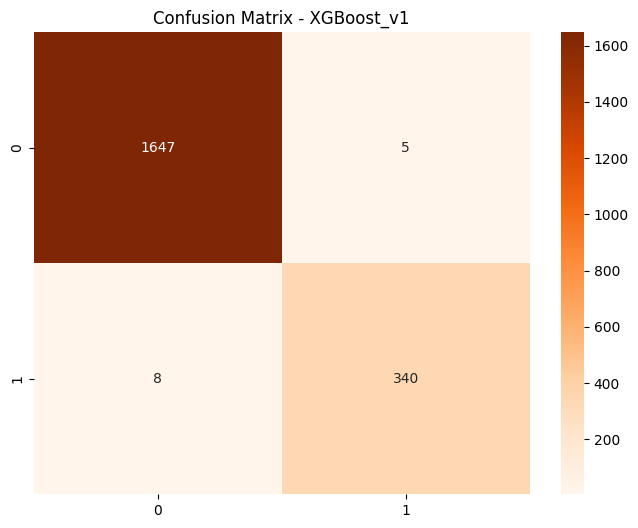

In [ ]:
from xgboost import XGBClassifier  # 1. Importation du moteur XGBoost

# 2. Configuration de l'expérience
xgb_experiment = mlflow.set_experiment("XGBoost_Models") 
run_name = "XGBoost_v1"
artifact_path = "xgb_v1"

# 3. Hyperparamètres typiques pour XGBoost
params = {
    "n_estimators": 50,      # Nombre de cycles de boosting
    "learning_rate": 0.05,     # Pas d'apprentissage (vitesse de convergence)
    "max_depth": 3,           # Profondeur des arbres
    "objective": "binary:logistic",  # reg:squarederror
    "random_state": 888  # Métrique d'évaluation interne
}


# 4. Initialisation et entraînement
xgb_model = XGBClassifier(**params)
xgb_model.fit(X_train_scaled, y_train)        

# Prédictions
y_pred = xgb_model.predict(X_test_scaled)
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

# --- Calcul des métriques ---
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probs) 
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
metrics = {"accuracy" : accuracy, "precision": precision, "recall": recall, "roc_auc": roc_auc, "f1": f1}

# --- Graphique (Matrice de Confusion) ---
conf_matrix = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Oranges', ax=ax) # Couleur Orange pour XGBoost
ax.set_title(f'Confusion Matrix - {run_name}')

# --- MLflow ---
if mlflow.active_run():
    mlflow.end_run()

with mlflow.start_run(run_name=run_name) as run:
    mlflow.log_params(params)
    mlflow.log_metrics(metrics)
    mlflow.sklearn.log_model(sk_model=xgb_model, input_example=X_test_scaled, artifact_path=artifact_path)

plt.show()